# Домашнее задание 5

## Информация перед выполнением

**Указания:**

1. Отвечать на вопросы в чате надо описанием идеи или ссылкой на источники - не лишайте других радости от **самостоятельно** найденного решения!
2. Перед отправкой на проверку перезапустите ядро и запустите подряд все ячейки. Это можно сделать руками, а можно через Kernel --> Restart Kernel and Run All Cells, но второй вариант сработает только если ячейки запускаются без ошибок). Если есть ошибки, которые вы хотите показать проверяющему, то продолжите выполнять ячейки руками.
3. Если какую-то задачу сделать не получилось, то в виде **комментария к ячейке** с кодом этой задачи опишите ход ваших мыслей или вопрос. **Комментарий к ячейке** вы можете оставить **только** в колабе: ПКМ по ячейке --> "оставить комментарий". Так проверяющий сможет вам помочь.
4. Нерешенные задачи без вашего **комментария к ячейке** считаются нетронутыми, даже если в них есть код.
5. Максимум за задание 10.5 первичных баллов
6. Итоговая оценка ставится по формуле: `сумма_баллов // 2`

**Примечания и советы:**

- Называйте переменные осмысленно
- Сначала решите все задачи, которые сразу понимаете как решать
- Если застряли на какой-то задаче, то попробуйте переключиться на другую
- Стиль оформления кода должен соответствовать PEP8; строго это не отслеживается, но в случае злоупотреблений вас попросят переписать
- Проверяйте работоспособность вашего кода на ячейках с тестами
- Тесты не являются гарантией, что все хорошо
- В тестах можно подсмотреть, как функция будет использоваться
- Не запрещено создавать дополнительные функции в той же ячейке с кодом, если это вам поможет, например, логически структурировать код
- Проверьте, что все ячейки выполняются без ошибок
- В отправляемом на проверку ноутбуке не должно быть черновых ячеек - за них будут сниматься баллы
- Проверяющий запускает код только при необходимости для проверки на собственных тестах

**Для статистики:**

- Просьба указывать используемые источники (в виде текстовой ячейки после кода), если вы нашли решение/идею/подсказку/etc в интернете/чате/etc.
- Если таких источников несколько - просьба указать хотя бы 2-3 основных.
- Если вы взяли чужое решение задачи, об этом также нужно указать.

Если вы прочитали все пункты, поменяйте значение переменной `i_have_read_all_the_information` в коде ниже на `True` и запустите ячейку.

In [4]:
i_have_read_all_the_information = True

assert i_have_read_all_the_information

# Часть 0. Простые функции Python. (1.5 балла)

Представьте тестирование, в котором экзаменуемому дают несколько последовательных вопросов, и на каждый из них он проставляет ответ `1` или `0`.

- параметры `ans` и `gt` - строго позиционные
- параметр `ndigits` - необязательный, строго именованный. Если он задан, то значение, возвращаемое функцией, округляется до `ndigits` знаков после запятой.

**Примечание:** 

- ans - сокращение от answer - проставленные ответы, список из 0 и 1
- gt - сокращение от ground truth - правильные ответы, список из 0 и 1
- каждая задача этой части по 0.3 балла

## Задача 1

Напишите функцию `accuracy(ans, gt, ndigits)`, считающую долю правильных ответов. 

In [1]:
def accuracy(ans, gt, ndigits=4):
    correct = sum(1 for a, g in zip(ans, gt) if a == g)
    return round(correct / len(gt), ndigits) if len(gt) > 0 else 0.0

## Задача 2

Напишите функцию `true_positive_rate(ans, gt, ndigits)`, считающую долю правильно отмеченных единиц.

In [2]:
def true_positive_rate(ans, gt, ndigits=4):
    actual_ones = sum(1 for g in gt if g == 1)
    if actual_ones == 0:
        return 0.0
    tp = sum(1 for a, g in zip(ans, gt) if a == 1 and g == 1)
    return round(tp / actual_ones, ndigits)

## Задача 3

Напишите функцию `false_positive_rate(ans, gt, ndigits)`, считающую долю неправильно отмеченных единиц.

In [3]:
def false_positive_rate(ans, gt, ndigits=4):
    actual_zeros = sum(1 for g in gt if g == 0)
    if actual_zeros == 0:
        return 0.0
    fp = sum(1 for a, g in zip(ans, gt) if a == 1 and g == 0)
    return round(fp / actual_zeros, ndigits)

## Задача 4

Напишите функцию `true_negative_rate(ans, gt, ndigits)`, считающую долю правильно отмеченных нулей.

In [4]:
def true_negative_rate(ans, gt, ndigits=4):
    actual_zeros = sum(1 for g in gt if g == 0)
    if actual_zeros == 0:
        return 0.0
    tn = sum(1 for a, g in zip(ans, gt) if a == 0 and g == 0)
    return round(tn / actual_zeros, ndigits)

## Задача 5

Напишите функцию `false_negative(ans, gt, ndigits)`, считающую долю неправильно отмеченных нулей.

In [5]:
def false_negative(ans, gt, ndigits=4):
    actual_ones = sum(1 for g in gt if g == 1)
    if actual_ones == 0:
        return 0.0
    fn = sum(1 for a, g in zip(ans, gt) if a == 0 and g == 1)
    return round(fn / actual_ones, ndigits)

# Часть 1. Декораторы. (4 балла)

## Задача 6

Напишите декоратор `timing`, который будет считать время выполнения последнего вызова функции в секундах и сохранять его в атрибуте `last_time`. Для работы со временем используйте встроенный модуль.

In [6]:
import time
from functools import wraps

def timing(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.perf_counter()  
        res = func(*args, **kwargs)
        wrapper.last_time = time.perf_counter() - start_time
        return res
    
    wrapper.last_time = 0.0  
    return wrapper

## Задача 7

Напишите декоратор `calls_counter`, который будет считать число рекурсивных вызовов функции во время ее последнего вызова и сохранять в атрибуте `calls`.

In [7]:
def calls_counter(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        if wrapper._depth == 0:
            wrapper._current_calls = 0
            
        wrapper._current_calls += 1
        wrapper._depth += 1
        
        try:
            res = func(*args, **kwargs)
        finally:
            wrapper._depth -= 1
            if wrapper._depth == 0:
                wrapper.calls = wrapper._current_calls
                
        return res

    wrapper.calls = 0          
    wrapper._current_calls = 0 
    wrapper._depth = 0         
    return wrapper

## Задача 8

Придумайте функцию, подходящую для тестирования предыдущих декораторов и протестируйте их.

In [8]:
@timing
@calls_counter
def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)

In [9]:
# 1. Тестирование метрик
answers = [1, 1, 0, 0, 1, 0]
ground_truth = [1, 0, 0, 1, 1, 0]

print(f"Accuracy: {accuracy(answers, ground_truth)}")        
print(f"TPR:      {true_positive_rate(answers, ground_truth)}") 
print(f"FPR:      {false_positive_rate(answers, ground_truth)}")
print(f"TNR:      {true_negative_rate(answers, ground_truth)}") 
print(f"FNR:      {false_negative(answers, ground_truth)}")    

# 2. Тестирование декораторов

res_large = fibonacci(25)
print(f"\nФибоначчи(25) = {res_large}")
print(f"Количество вызовов функции: {fibonacci.calls}")
print(f"Время выполнения вызова: {fibonacci.last_time:.6f} сек.")

fibonacci(3)
print(f"\nПосле перезапуска для n=3, вызовов стало: {fibonacci.calls}")



Accuracy: 0.6667
TPR:      0.6667
FPR:      0.3333
TNR:      0.6667
FNR:      0.3333

Фибоначчи(25) = 75025
Количество вызовов функции: 0
Время выполнения вызова: 0.209099 сек.

После перезапуска для n=3, вызовов стало: 0


## Задача 9

Декорировать можно не только функции, но и классы. Напишите декоратор `single`, который будет превращать класс в синглтон: класс, обладающий только одним экземпляром.

Подсказка: `__new__`

In [10]:
def single(cls):
    old_new = cls.__new__
    instance = None

    def new_singleton(cls_obj, *args, **kwargs):
        nonlocal instance
        if instance is None:
            if old_new is object.__new__:
                instance = old_new(cls_obj)
            else:
                instance = old_new(cls_obj, *args, **kwargs)
        return instance

    cls.__new__ = new_singleton
    return cls

In [11]:
# tests

@single
class Test:
    pass

a = Test()
b = Test()
assert a is b

# Часть 2. NumPy. (2 балла)

**Примечание:** 

- использовать функции и методы `np`
- циклы использовать нельзя
- в большинстве задача требуется просто правильно вызвать 1-2 метода
- все задачи с 10 по 26 стоят 0.1 балла, а 27 стоит 0.3 балла

In [12]:
import numpy as np

## Работа с одномерными массивами

### Задача 10

Создайте функцию `create_array(n, m)`, которая может принимать на вход как один список чисел, так и сразу два целых числа `n` и `m`. В первом случае массив numpy создается из списка, а во втором - от `n` до `m` включительно с шагом 1.

In [13]:
def create_array(*args):
    if len(args) == 1 and isinstance(args[0], (list, tuple)):
        return np.array(args[0])
    elif len(args) == 2 and isinstance(args[0], int) and isinstance(args[1], int):
        return np.arange(args[0], args[1] + 1)
    else:
        raise TypeError("Неверные аргументы. Передайте список или два целых числа (n, m)")


print(create_array([1, 5, 10])) 
print(create_array(1, 5))       

[ 1  5 10]
[1 2 3 4 5]


### Задача 11

Создайте массив numpy размером $a×b$ со всеми значениями, равными `True`. Cчитайте, что a и b вам уже заданы.

Подсказка: создайте массив из единиц и воспользуйтесь приведением типа.

In [14]:
a = 3
b = 4

In [15]:
result_11 = np.ones((a, b), dtype=bool)

print(result_11)


[[ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]]


### Задача 12

Вам дан массив под названием `test_array`. Выведите положительные элементы этого массива.

In [16]:
test_array = np.array([ 0, -1,  5, -3,  7, -1,  6, -1,  8, -1])

result_12 = test_array[test_array > 0]

print(result_12)

[5 7 6 8]


`array([5, 7, 6, 8])`

### Задача 13

Замените отрицательные элементы из массива `test_array` на `0`.

*Подсказка:* вам может пригодится функция `np.where`.

In [17]:
test_array = np.array([ 0, -1,  5, -3,  7, -1,  6, -1,  8, -1])

result_13 = np.where(test_array >= 0, test_array, 0)

print(result_13)


[0 0 5 0 7 0 6 0 8 0]


`array([0, 0, 5, 0, 7, 0, 6, 0, 8, 0])`

### Задача 14

Вам дан массив из 10 чисел. Найдите позицию максимального элемента в заданном массиве.

In [18]:
array = np.array([6, 8, 4, 2, 11, -3, 7, 22, -20, -30])

In [19]:
result_14 = np.argmax(array)

print(result_14)

7


`7`

### Задача 15

Вам дан словарь, в котором подсчитаны частоты женских имен в выборке из 26 новорожденных девочек.

In [20]:
names = dict()
names['Катя'] = 8
names["Маша"] = 5
names["Вероника"] = 2
names["Ярослава"] = 1
names["Александра"] = 10

counts = np.array(list(names.values()))

result_15 = counts / np.sum(counts)



Посчитайте процентные доли имен с помощью нормирования вектора значений.

*Подсказка:* просто возьмите этот вектор значений и поделите его на сумму элементов в нем

In [21]:
print(result_15)

[0.30769231 0.19230769 0.07692308 0.03846154 0.38461538]


`array([0.30769231, 0.19230769, 0.07692308, 0.03846154, 0.38461538])`

**Примечание:** мы только что произвели операцию **нормирования вектора** (теперь его элементы суммируются в 1), а получившиеся элементы можно интерпретировать как **вероятности** (в примере выше это вероятности того, что случайно взятая новорожденная девочка будет иметь какое-то конкретное имя)

## Работа с двумерными массивами

### Задача 16

Создайте одномерный массив из 12 элементов от 0 до 11 и сделайте из него матрицу размером 3х4 (`np.reshape`)

In [22]:
result_16 = np.arange(12).reshape(3, 4)

print(result_16)


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


```
array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])
```

### Задача 17

Соедините вертикально две созданные матрицы `a` и `b`.

In [23]:
a = np.arange(8).reshape(2, 4)
b = np.ones(8).reshape(2, 4)

In [24]:
a = np.arange(8).reshape(2, 4)
b = np.ones(8).reshape(2, 4)

result_17 = np.vstack((a, b))

print(result_17)

[[0. 1. 2. 3.]
 [4. 5. 6. 7.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


```
array([[0., 1., 2., 3.],
       [4., 5., 6., 7.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])
```

### Задача 18

Теперь соедините эти же две матрицы горизонтально.

In [25]:
a = np.arange(8).reshape(2, 4)
b = np.ones(8).reshape(2, 4)

result_18 = np.hstack((a, b))  

print(result_18)

[[0. 1. 2. 3. 1. 1. 1. 1.]
 [4. 5. 6. 7. 1. 1. 1. 1.]]


```
array([[0., 1., 2., 3., 1., 1., 1., 1.],
       [4., 5., 6., 7., 1., 1., 1., 1.]])
```

### Задача 19

Сохраните в отдельную переменную второй столбец (столбец с индексом 1) из данного вам двумерного массива.

**Примечание:** при вырезании столбца из матрицы, у вас получится одномерный numpy-array, а не двумерная матрица с одним столбцом!

In [26]:
arr = np.arange(12).reshape(3, 4)
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [27]:
result_19 = arr[:, 1]

print(result_19)


[1 5 9]


```
array([1, 5, 9])
```

### Задача 20

Создайте массив из случайных чисел размера 3 на 4 (3 строки и 4 столбца) и сохраните его в переменную `random_array`. Найдите среднее, медиану, стандартное отклонение созданной матрицы `random_array` по строкам и по столбцам.

**Вывод вашего кода** - по одной строке на среднее, медиану, и стандартное отклонение для операций по строкам и по столбцам (всего 6 строк кода).

In [28]:
random_array = np.random.randn(3, 4)

print("Среднее по строкам:", np.mean(random_array, axis=1))
print("Медиана по строкам:", np.median(random_array, axis=1))
print("Стандартное отклонение по строкам:", np.std(random_array, axis=1))

print("Среднее по столбцам:", np.mean(random_array, axis=0))
print("Медиана по столбцам:", np.median(random_array, axis=0))
print("Стандартное отклонение по столбцам:", np.std(random_array, axis=0))


Среднее по строкам: [ 0.45495119  0.02649387 -0.19669462]
Медиана по строкам: [ 0.50908471  0.38064804 -0.1790763 ]
Стандартное отклонение по строкам: [0.51747638 1.07874626 0.30010206]
Среднее по столбцам: [-0.33097141 -0.10600911  0.26035879  0.55628899]
Медиана по столбцам: [-0.41378731 -0.09351271  0.0556347   0.67564964]
Стандартное отклонение по столбцам: [1.14367415 0.37142906 0.56619296 0.30440386]


### Задача 21

Найдите средние значения по строкам у созданной в 21-ой задаче матрицы `random_array`. Вычтите полученные средние значения из соответствующих строк изначальной матрицы `random_array`. Проверьте, что после вычитания средних, среднее по каждой строке стало равно 0.

In [29]:
row_means = np.mean(random_array, axis=1, keepdims=True)

centered_array = random_array - row_means

print(np.mean(centered_array, axis=1))


[-4.16333634e-17 -5.55111512e-17  0.00000000e+00]


### Задача 22

Запрограммируйте вычисление следующей формулы с помощью numpy:

$$
y = x + 2\sqrt{x} + 8 \cos (\frac{x^2}{5})
$$

In [30]:
x = np.linspace(0, 10, 100)

y = x + 2 * np.sqrt(x) + 8 * np.cos(x**2 / 5)


И постройте ее график (достаточно запустить ячейку с кодом ниже)

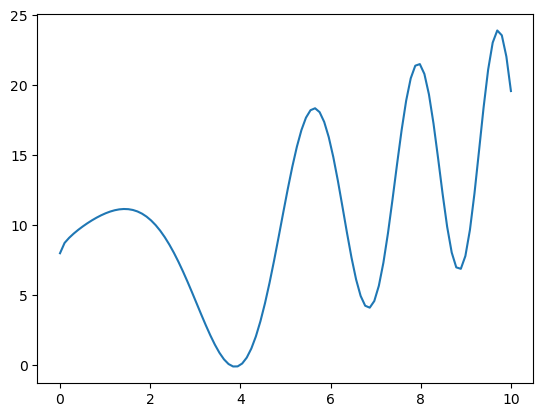

In [31]:
from matplotlib import pyplot as plt

plt.plot(x, y)
# plt.show()

### Задача 23

Создайте случайный вектор размера 10, и замените в нем максимальное значение на 0.

In [32]:
vector = np.random.rand(10)

vector[vector.argmax()] = 0


### Задача 24

Найдите общие элементы двух numpy массивов (воспользуйтесь готовой функцией).

In [33]:
arr1 = np.random.randint(0, 10, 10)
arr2 = np.random.randint(0, 10, 10)

In [34]:
print(arr1)
print(arr2)
arr3 = np.intersect1d(arr1, arr2)
print(arr3)

[1 6 5 4 5 7 7 0 8 9]
[3 0 3 0 7 2 8 4 1 1]
[0 1 4 7 8]


### Задача 25

Пусть мы имеем 2 массива (заданы ниже в коде). Требуется создать массив, который содержит в себе `True` на соответствующей позиции, если элемент с четным индексом 1-го массива больше соответствующего элемента 2-го и `True`, если нечетный (по индексу) элемент 2-го больше элемента 1-го. В противном случае `False`.

Реализовать задачу с помощью numpy.

Пример массивов и результата:

```
a = [7, 3, 5, 9, 2, 5, 4, 8, 9, 0]
b = [2, 8, 6, 7, 1, 3, 2, 9, 5, 1]
res = [ True, True, False, False, True, False, True, True, True, True]
```

Вы можете сделать задачу с помощью слайсинга или комбинации функций `np.arange` и `np.where`.

In [35]:
a = np.random.randint(0, 10, 10)
b = np.random.randint(0, 10, 10)
print(a)
print(b)

[8 4 9 5 9 9 2 5 1 7]
[9 1 3 8 3 0 5 2 2 4]


In [36]:
indices = np.arange(len(a))

res = np.where(indices % 2 == 0, a > b, b > a)

print(res)

[False False  True  True  True False False False False False]


### Задача 26

Создайте массив размера 10 со значениями от 0 до 1 (интервал между значениями равномерный), не включая концы.

*Примечание:* см. `np.linspace` + слайсинг

In [37]:
result_26 = np.linspace(0, 1, 12)[1:-1]

print(result_26)


[0.09090909 0.18181818 0.27272727 0.36363636 0.45454545 0.54545455
 0.63636364 0.72727273 0.81818182 0.90909091]


### Задача 27

**Реализуйте задачу с и без помощи numpy, сравните время выполнения.**

Написать две функции `py_mean(n)` и `np_mean(n)`, каждая из которых принимает на вход целое число `n` - длину последовательности, генерирует ее (использовать `range` и `np.arange`), а затем находит и возвращает среднее арифметическое ее членов (вам помогут `sum` и `np.mean`).

Важно, что в одном случае вы должны использоваться только чистый Python, а в случае с numpy работать нужно **только** с его абстракциями (от создания массива и заканчивая вычислением).

Произведите измерения для различных размеров выборки: `1e3, 1e4, 1e5, 1e6, 1e7`.

In [38]:
%%time
print('Указывайте %%time в начале клетки, чтобы посмотреть время её выполнения')

Указывайте %%time в начале клетки, чтобы посмотреть время её выполнения
CPU times: total: 0 ns
Wall time: 174 μs


In [39]:
def py_mean(n):
    seq = range(int(n))
    return sum(seq) / len(seq) if n > 0 else 0

In [40]:
def np_mean(n):
    seq = np.arange(int(n))
    return np.mean(seq)

In [41]:
for size in [1e3, 1e4, 1e5, 1e6, 1e7]:
    print(f"\n--- Размер выборки: {size:.0e} ---")
    
    start = time.perf_counter()
    py_mean(size)
    print(f"Чистый Python: {time.perf_counter() - start:.6f} сек.")
    
    start = time.perf_counter()
    np_mean(size)
    print(f"NumPy:         {time.perf_counter() - start:.6f} сек.")


--- Размер выборки: 1e+03 ---
Чистый Python: 0.000027 сек.
NumPy:         0.000113 сек.

--- Размер выборки: 1e+04 ---
Чистый Python: 0.000239 сек.
NumPy:         0.000421 сек.

--- Размер выборки: 1e+05 ---
Чистый Python: 0.002555 сек.
NumPy:         0.000517 сек.

--- Размер выборки: 1e+06 ---
Чистый Python: 0.025413 сек.
NumPy:         0.004855 сек.

--- Размер выборки: 1e+07 ---
Чистый Python: 0.217145 сек.
NumPy:         0.053357 сек.


# Часть 3. Файлы (2.5 балла)

Дальнейшие задачи лучше выполнить локально (и не удалять вывод ячеек)

Скачайте архив по ссылке и положите в директорию с ноутбуком.

- https://drive.google.com/file/d/1-OaQektHIr8v2AYC5ac9J8zXULBngPa9/view?usp=sharing

## Задача 28 (0.2)

С помощью `pathlib` убедитесь, что архив есть.

In [44]:
from pathlib import Path

archive_path = Path("roll.zip")

if archive_path.exists():
    print(f"Архив найден! Размер: {archive_path.stat().st_size / (1024**2):.2f} МБ")
else:
    print("Архива нет в текущей директории. Проверьте путь.")


Архив найден! Размер: 424.58 МБ


## Задача 29 (0.8)

Найдите способ разархивировать его с помощью кода (Python или команды в терминале). Процесс разархивации может занять время.

In [ ]:
import zipfile

with zipfile.ZipFile("roll.zip", "r") as zip_ref:
    zip_ref.extractall("extracted_roll")

print("Распаковка полностью завершена!")

## Задача 30* (2)

**Внимание:** это задание со звездочкой ;)

Задание слегка творческое. У вас есть начальная точка: распакованный архив. Нужно добраться до конечной точки: собрать массив `arrgb`.

Выдвигайте гипотезы и идеи, записывайте их в текстовых ячейках и проверяйте с помощью кода. Для этого создавайте дополнительные ячейки.

Например:

посмотрим, сколько директорий в распакованном архиве:

In [2]:
from pathlib import Path
import os

extracted_dir = Path("extracted_roll")
for path in extracted_dir.glob("*"):
    print(path)

extracted_roll\.DS_Store
extracted_roll\dir0
extracted_roll\dir1
extracted_roll\dir10
extracted_roll\dir100
extracted_roll\dir101
extracted_roll\dir102
extracted_roll\dir103
extracted_roll\dir104
extracted_roll\dir105
extracted_roll\dir106
extracted_roll\dir107
extracted_roll\dir108
extracted_roll\dir109
extracted_roll\dir11
extracted_roll\dir110
extracted_roll\dir111
extracted_roll\dir112
extracted_roll\dir113
extracted_roll\dir114
extracted_roll\dir115
extracted_roll\dir116
extracted_roll\dir117
extracted_roll\dir118
extracted_roll\dir119
extracted_roll\dir12
extracted_roll\dir120
extracted_roll\dir121
extracted_roll\dir122
extracted_roll\dir123
extracted_roll\dir124
extracted_roll\dir125
extracted_roll\dir126
extracted_roll\dir127
extracted_roll\dir128
extracted_roll\dir129
extracted_roll\dir13
extracted_roll\dir130
extracted_roll\dir131
extracted_roll\dir132
extracted_roll\dir133
extracted_roll\dir134
extracted_roll\dir135
extracted_roll\dir136
extracted_roll\dir137
extracted_roll\

Если вы все сделали правильно, то после запуска следующей ячейки вас ждет приз:

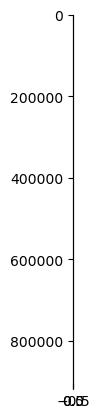

In [7]:
import matplotlib.pyplot as plt

plt.imshow(arrgb);

In [8]:
from pathlib import Path

extracted_dir = Path("extracted_roll")
all_txt_files = [f for f in extracted_dir.glob("**/*.txt") if f.is_file()]

for f in all_txt_files[:10]:
    print(f"Путь: {f.parent} | Имя файла: {f.name}")

Путь: extracted_roll\dir99\dir0 | Имя файла: file0.txt
Путь: extracted_roll\dir99\dir0 | Имя файла: file1.txt
Путь: extracted_roll\dir99\dir0 | Имя файла: file2.txt
Путь: extracted_roll\dir99\dir1 | Имя файла: file0.txt
Путь: extracted_roll\dir99\dir1 | Имя файла: file1.txt
Путь: extracted_roll\dir99\dir1 | Имя файла: file2.txt
Путь: extracted_roll\dir99\dir10 | Имя файла: file0.txt
Путь: extracted_roll\dir99\dir10 | Имя файла: file1.txt
Путь: extracted_roll\dir99\dir10 | Имя файла: file2.txt
Путь: extracted_roll\dir99\dir100 | Имя файла: file0.txt


In [9]:
import os
from pathlib import Path

extracted_dir = Path("extracted_roll")

top_dirs = set()
sub_dirs = set()

for p in extracted_dir.glob("dir*"):
    if p.is_dir():
        top_dirs.add(p.name)
        for sp in p.glob("dir*"):
            if sp.is_dir():
                sub_dirs.add(sp.name)

print(f"Количество строк (папок 1-го уровня): {len(top_dirs)}")
print(f"Количество столбцов/блоков (папок 2-го уровня): {len(sub_dirs)}")

Количество строк (папок 1-го уровня): 720
Количество столбцов/блоков (папок 2-го уровня): 1280
